# Data Preprocessing & Feature Engineering
**Dataset Source:** https://www.kaggle.com/datasets/spscientist/students-performance-in-exams

This notebook demonstrates data preprocessing and feature engineering using a simple dataset.


In [60]:
import pandas as pd
import numpy as np

We load the dataset using pandas and check the first few rows, data types, and summary statistics. This helps us understand the structure and detect missing values or anomalies.

In [61]:
df = pd.read_csv("C:\\Users\\Nishtha Srivastava\\Downloads\\archive (4)\\Student_performance_10k.csv")



In [62]:
print(df.head())


  roll_no gender race_ethnicity parental_level_of_education  lunch  \
0  std-01   male        group D                some college    1.0   
1  std-02   male        group B                 high school    1.0   
2  std-03   male        group C             master's degree    1.0   
3  std-04   male        group D                some college    1.0   
4  std-05   male        group C                some college    0.0   

   test_preparation_course math_score  reading_score  writing_score  \
0                      1.0         89           38.0           85.0   
1                      0.0         65          100.0           67.0   
2                      0.0         10           99.0           97.0   
3                      1.0         22           51.0           41.0   
4                      1.0         26           58.0           64.0   

   science_score  total_score grade  
0           26.0        238.0     C  
1           96.0        328.0     A  
2           58.0        264.0     B  


In [63]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   roll_no                      9999 non-null   object 
 1   gender                       9982 non-null   object 
 2   race_ethnicity               9977 non-null   object 
 3   parental_level_of_education  9978 non-null   object 
 4   lunch                        9976 non-null   float64
 5   test_preparation_course      9977 non-null   float64
 6   math_score                   9976 non-null   object 
 7   reading_score                9975 non-null   float64
 8   writing_score                9976 non-null   float64
 9   science_score                9977 non-null   float64
 10  total_score                  9981 non-null   float64
 11  grade                        9997 non-null   object 
dtypes: float64(6), object(6)
memory usage: 937.6+ KB


In [64]:
df.describe()

,lunch,test_preparation_course,reading_score,writing_score,science_score,total_score
count,9976.000000,9977.000000,9975.000000,9976.000000,9977.000000,9981.000000
mean,0.644246,0.388694,70.125915,71.415798,66.063045,264.740908
std,0.478765,0.487478,19.026245,18.245360,19.324331,42.304858
min,0.000000,0.000000,17.000000,10.000000,9.000000,89.000000
25%,0.000000,0.000000,57.000000,59.000000,53.000000,237.000000
50%,1.000000,0.000000,71.000000,72.500000,67.000000,268.000000
75%,1.000000,1.000000,85.000000,85.000000,81.000000,294.000000
max,1.000000,1.000000,100.000000,100.000000,100.000000,383.000000


We identify missing values.

In [65]:
print(df.isnull().sum())

roll_no                         1
gender                         18
race_ethnicity                 23
parental_level_of_education    22
lunch                          24
test_preparation_course        23
math_score                     24
reading_score                  25
writing_score                  24
science_score                  23
total_score                    19
grade                           3
dtype: int64


In [66]:
# # Convert math_score to numeric
df["math_score"] = pd.to_numeric(df["math_score"], errors="coerce")


In [67]:
print(df["math_score"].head())

0    89.0
1    65.0
2    10.0
3    22.0
4    26.0
Name: math_score, dtype: float64


# Numerical imputation: fill missing math scores with mean
# Categorical imputation: fill missing gender with mode
For numerical values, mean imputation is simple and effective and for categorical values, mode imputation ensures consistency by filling with the most frequent category.

In [68]:
df["math_score"] = df["math_score"].fillna(df["math_score"].mean())


In [69]:
print(df["math_score"].isnull().sum())

0


In [70]:
print(df["math_score"].dtype)

float64


In [71]:
df["gender"] = df["gender"].fillna(df["gender"].mode()[0])

 Handling Outliers:
Outliers are detected using the IQR method. Some may be valid (e.g., very high scores), while others may be errors (e.g., negative values if present).

In [72]:
# Calculate IQR for math_score
Q1 = df["math_score"].quantile(0.25)
Q3 = df["math_score"].quantile(0.75)
IQR = Q3 - Q1

# Define outlier boundaries
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Detect outliers
outliers = df[(df["math_score"] < lower_bound) | (df["math_score"] > upper_bound)]
print("Number of outliers detected:", len(outliers))
print(outliers[["math_score"]].head())


Number of outliers detected: 0
Empty DataFrame
Columns: [math_score]
Index: []



Using the IQR method, we checked for outliers in `math_score`.  
Result: **No outliers were detected**.  

This means all values lie within the acceptable range defined by `[Q1 - 1.5*IQR, Q3 + 1.5*IQR]`.  
In practice:
- If outliers exist, we decide whether they are **valid observations** (e.g., very high achievers) or **errors** (e.g., impossible negative scores).  
- Since none were found here, no removal or correction is needed.

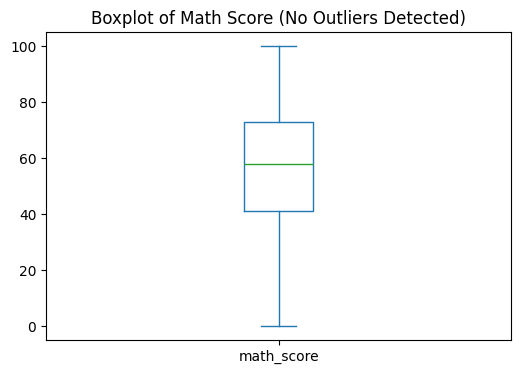

In [73]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
df["math_score"].plot(kind="box")
plt.title("Boxplot of Math Score (No Outliers Detected)")
plt.show()

Transformations:
Scaling ensures numerical features are on the same scale and encoding converts categorical variables into numeric form for modeling.


In [74]:
from sklearn.preprocessing import MinMaxScaler, LabelEncoder


In [75]:
# Scaling math score

scaler = MinMaxScaler()
df["math_scaled"] = scaler.fit_transform(df[["math_score"]])




In [76]:
# Encoding categorical variable (gender)
encoder = LabelEncoder()
df["gender_encoded"] = encoder.fit_transform(df["gender"])


Feature Engineering:
math_performance: Converts the scaled math score into categories (Low, Medium, High). This helps in classification tasks and makes interpretation easier.
avg_score: Represents the overall academic performance by averaging across subjects. This feature is useful for regression models or clustering students by performance.



In [77]:
# 1. Create a performance category based on scaled math score
df["math_performance"] = df["math_scaled"].apply(
    lambda x: "Low" if x < 0.4 else ("Medium" if x < 0.7 else "High")
)


In [78]:
# 2. Create an overall average score feature
df["avg_score"] = df[["math_score", "reading_score", "writing_score", "science_score"]].mean(axis=1)



In [79]:
print(df[["math_score", "math_scaled", "math_performance", "avg_score"]].head())

   math_score  math_scaled math_performance  avg_score
0        89.0         0.89             High      59.50
1        65.0         0.65           Medium      82.00
2        10.0         0.10              Low      66.00
3        22.0         0.22              Low      49.50
4        26.0         0.26              Low      53.25
